# 数据集预处理
针对单个数据集进行严格的：
- 设置随机种子
- 样本筛选
- 细胞质控
- 去除环境污染（是否需要？）
- 保存质控后数据至'UC/scRNA-seq_data/03_qc_filtered'文件夹
- 批次效应查看
- 降维聚类结果
- 处理异常细胞群
- 区分主要谱系

# 文件说明
- **文件名**: 5_GSE134649_qc.h5ad 
- **存放位置**: 坚果云  `UC/scRNA-seq_data/03_qc_filtered/`  
- **生成日期**: 2025-11-4  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/1.2_qc_filtered/5_GSE134649.ipynb  
- **内容说明**: 完成了针对单个数据的预处理工作，包括样本排除、细胞质控，并查看了样本间的批次效应。  

In [1]:
import numpy as np
import random
np.random.seed(42)
random.seed(42)

In [2]:
import scanpy as sc
#sc.settings.verbosity = 1
print(sc.__version__)

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


1.11.4


## 读取数据
GSE134649数据集：
- 结肠组织 CD8+ T Cell 样本
- 3UC，3HC

In [3]:
adata = sc.read_h5ad('/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/02_sample_merge/5_GSE134649.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 10282 × 12107
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells'
    uns: 'REFERENCE_MANU', 'scrublet', 'status', 'status_args'

In [5]:
adata.obs.head()

,n_genes,GSM_id,GSM,id,nUMIs,mito_perc,detected_genes,cell_complexity,passing_mt,passing_nUMIs,passing_ngenes,doublet_score,predicted_doublet
GSM3960983_HC14_AAACCTGAGTGCCATT-1,729,GSM3960983_HC14,GSM3960983,HC14,1552.0,0.110825,729,0.469716,True,True,True,0.057022,False
GSM3960983_HC14_AAACCTGCAATGCCAT-1,1236,GSM3960983_HC14,GSM3960983,HC14,2742.0,0.085704,1236,0.450766,True,True,True,0.238731,False
GSM3960983_HC14_AAACCTGGTGCACTTA-1,1912,GSM3960983_HC14,GSM3960983,HC14,4796.0,0.064012,1912,0.398666,True,True,True,0.131213,False
GSM3960983_HC14_AAACGGGGTGTCCTCT-1,1453,GSM3960983_HC14,GSM3960983,HC14,4577.0,0.079091,1453,0.317457,True,True,True,0.055412,False
GSM3960983_HC14_AAACGGGTCCGCAAGC-1,1373,GSM3960983_HC14,GSM3960983,HC14,3899.0,0.067966,1373,0.352142,True,True,True,0.082759,False


## 处理细胞标签及分组

In [6]:
# 提取分组信息
import pandas as pd
adata.obs['group'] = adata.obs['id'].str.extract(r'([A-Za-z]+)', expand=False)
print(adata.obs[['id', 'group']].head())

                                      id group
GSM3960983_HC14_AAACCTGAGTGCCATT-1  HC14    HC
GSM3960983_HC14_AAACCTGCAATGCCAT-1  HC14    HC
GSM3960983_HC14_AAACCTGGTGCACTTA-1  HC14    HC
GSM3960983_HC14_AAACGGGGTGTCCTCT-1  HC14    HC
GSM3960983_HC14_AAACGGGTCCGCAAGC-1  HC14    HC


`.obs`当中只保留GSM信息和分组信息

In [7]:
adata.obs.drop(columns=['GSM_id', 'id'], inplace=True)
print(adata.obs.head())

                                    n_genes         GSM   nUMIs  mito_perc  \
GSM3960983_HC14_AAACCTGAGTGCCATT-1      729  GSM3960983  1552.0   0.110825   
GSM3960983_HC14_AAACCTGCAATGCCAT-1     1236  GSM3960983  2742.0   0.085704   
GSM3960983_HC14_AAACCTGGTGCACTTA-1     1912  GSM3960983  4796.0   0.064012   
GSM3960983_HC14_AAACGGGGTGTCCTCT-1     1453  GSM3960983  4577.0   0.079091   
GSM3960983_HC14_AAACGGGTCCGCAAGC-1     1373  GSM3960983  3899.0   0.067966   

                                    detected_genes  cell_complexity  \
GSM3960983_HC14_AAACCTGAGTGCCATT-1             729         0.469716   
GSM3960983_HC14_AAACCTGCAATGCCAT-1            1236         0.450766   
GSM3960983_HC14_AAACCTGGTGCACTTA-1            1912         0.398666   
GSM3960983_HC14_AAACGGGGTGTCCTCT-1            1453         0.317457   
GSM3960983_HC14_AAACGGGTCCGCAAGC-1            1373         0.352142   

                                    passing_mt  passing_nUMIs  passing_ngenes  \
GSM3960983_HC14_AAACCTG

In [8]:
adata.obs['group'].value_counts()

group
UC    5593
HC    4689
Name: count, dtype: int64

## 样本质量查看

In [9]:
adata.obs['GSM'].value_counts()

GSM
GSM3960986    2125
GSM3960988    1960
GSM3960985    1930
GSM3960984    1714
GSM3960987    1508
GSM3960983    1045
Name: count, dtype: int64

In [10]:
sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])

print(sample_quality_stats)

                n_genes                               nUMIs               \
                   mean         std  min   max         mean          std   
GSM                                                                        
GSM3960983  1608.415311  523.772610  291  4557  4538.445801  1936.140625   
GSM3960984  1496.146441  470.191390  271  4340  4443.142578  1867.395142   
GSM3960985  1728.889119  543.108034  258  4240  4991.637207  2066.029541   
GSM3960986  1862.184941  663.143364  297  6451  5318.442383  2985.450439   
GSM3960987  1651.812997  540.582182  258  4303  4672.926270  2114.960938   
GSM3960988  1666.413265  594.627611  272  4184  4578.220703  2271.326172   

                           mito_perc                           
              min      max      mean       std  min       max  
GSM                                                            
GSM3960983  517.0  16464.0  0.071212  0.032978  0.0  0.198135  
GSM3960984  518.0  25636.0  0.087673  0.032782  0.0  0.1994

/tmp/ipykernel_10960/2761774101.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])


## 细胞质控

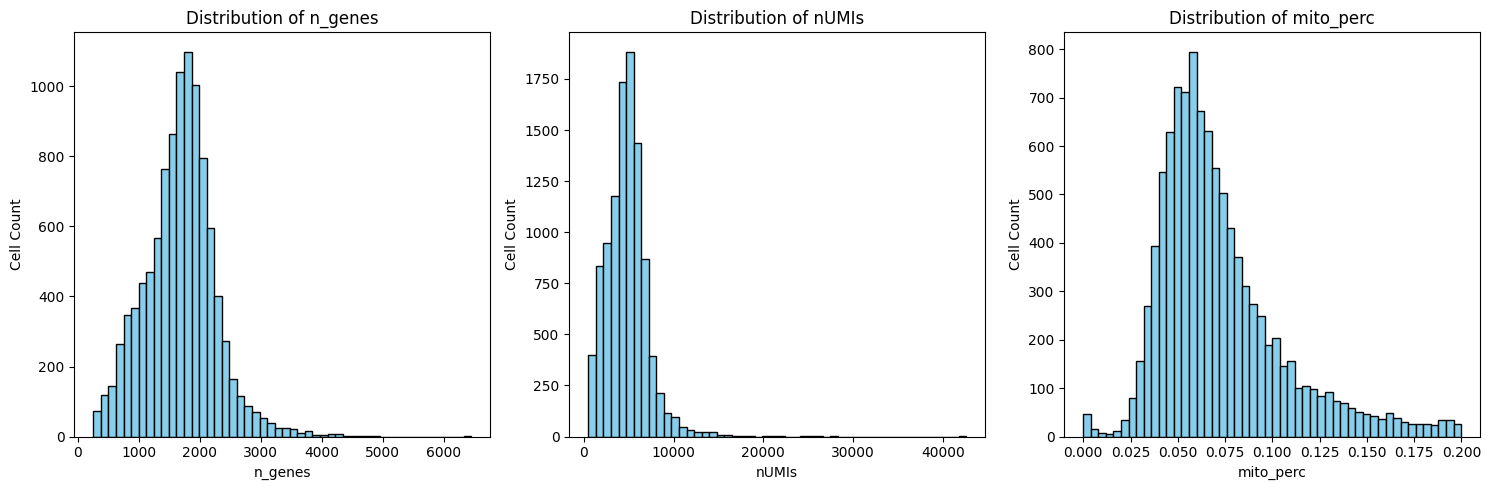

In [11]:
import matplotlib.pyplot as plt

# 选择要可视化的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 绘制各个指标的直方图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# 绘制每个质量控制指标的直方图
for i, metric in enumerate(qc_metrics):
    ax[i].hist(adata.obs[metric], bins=50, color='skyblue', edgecolor='black')
    ax[i].set_title(f'Distribution of {metric}')
    ax[i].set_xlabel(metric)
    ax[i].set_ylabel('Cell Count')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


/tmp/ipykernel_10960/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_10960/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')
/tmp/ipykernel_10960/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')


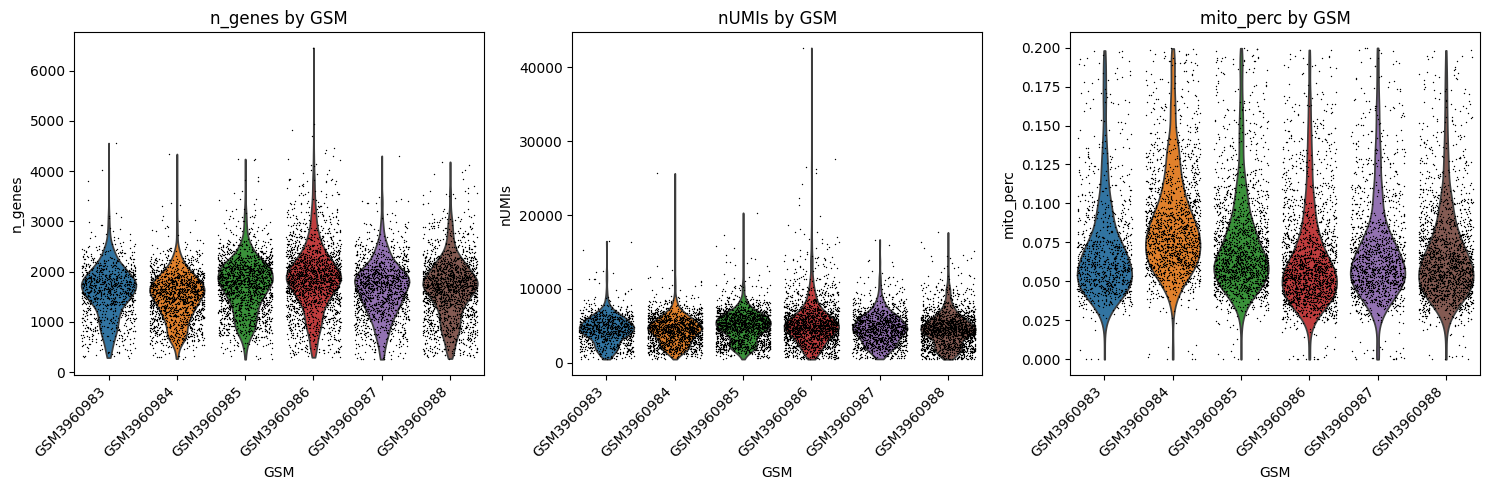

In [12]:
# 设置绘图风格
sc.settings.verbosity = 0  # 简化日志输出

# 选择要绘制的小提琴图的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 按照样本（GSM）绘制小提琴图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(qc_metrics):
    sc.pl.violin(adata, keys=metric, groupby='GSM', ax=ax[i], stripplot=True, jitter=0.4, show=False)
    ax[i].set_title(f'{metric} by GSM')
    ax[i].set_ylabel(f'{metric}')
    
    # 获取当前的x轴标签
    labels = ax[i].get_xticklabels()
    # 旋转标签并调整对齐方式（末尾对齐）
    ax[i].set_xticklabels(labels, rotation=45, ha='right')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


### 严格细胞质控标准
- min_genes = 200          # 最少基因数
- max_genes = 4000         # 最多基因数
- min_umis = 500           # 最少UMI数量
- max_umis = 20000         # 最多UMI数量
- max_mito_perc = 20       # 线粒体基因百分比最大值

In [ ]:
# 设置阈值
min_genes = 200          # 最少基因数
max_genes = 6000         # 最多基因数
min_umis = 500           # 最少UMI数量
max_umis = 20000        # 最多UMI数量
max_mito_perc = 0.2       # 线粒体基因百分比最大值

# 根据阈值进行过滤
adata = adata[(adata.obs['n_genes'] > min_genes) & 
              (adata.obs['n_genes'] < max_genes) &
              (adata.obs['nUMIs'] > min_umis) &
              (adata.obs['nUMIs'] < max_umis) &
              (adata.obs['mito_perc'] < max_mito_perc), :]

# 输出过滤后的细胞数
print(f'Number of cells after filtering: {adata.n_obs}')

Number of cells after filtering: 10272


## 保存质控后数据


In [14]:
import os
output_dir = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/03_qc_filtered/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "5_GSE134649_qc.h5ad"), compression='gzip')

## 降维聚类

In [15]:
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated


结肠组织 T细胞，所以选取1000个高变基因  
取resolution=0.4

In [16]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=1000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.4)

Begin robust gene identification
After filtration, 12107/12107 genes are kept.     Among 12107 genes, 12107 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell
The following highly-expressed genes are not considered during normalization factor computation:
['IGKV3-20', 'MALAT1', 'IGLV2-14']
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 1.0688800811767578 seconds.
End of size normalization: shiftlog and HVGs selection pearson
🚀 Using GPU to calculate PCA...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA Ge

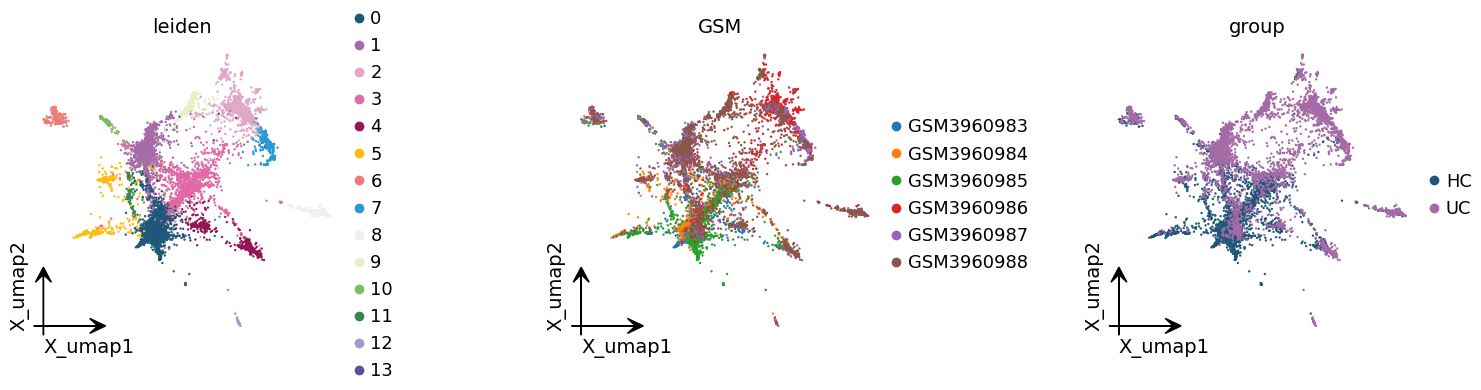

In [17]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

## 去除批次效应
按样本去除批次，看看是否效果会更好

使用`harmony`

In [21]:
ov.single.batch_correction(adata,
                           batch_key='GSM', # 去批次分组标签
                           methods='harmony',
                           n_pcs=50)
                           
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='X_harmony')

ov.pp.umap(adata)

ov.pp.leiden(adata,resolution=0.4)

2025-11-04 13:30:32,595 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


...Begin using harmony to correct batch effect


2025-11-04 13:30:34,297 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-04 13:30:34,338 - harmonypy - INFO - Iteration 1 of 10
2025-11-04 13:30:36,358 - harmonypy - INFO - Iteration 2 of 10
2025-11-04 13:30:38,253 - harmonypy - INFO - Iteration 3 of 10
2025-11-04 13:30:40,269 - harmonypy - INFO - Converged after 3 iterations


🖥️ Using Scanpy CPU to calculate neighbors...
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
🔍 [2025-11-04 13:30:41] Running UMAP in 'cpu-gpu-mixed' mode...
🚀 Using torch GPU to calculate UMAP...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    ||||-------------------------- 2359/16311 MiB (14.5%)
computing UMAP🚀
    finished ✅: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)
✅ UMAP completed successfully.
🖥️ Using Scanpy CPU Leiden...
running Leiden clustering
    finished: found 12 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:02)


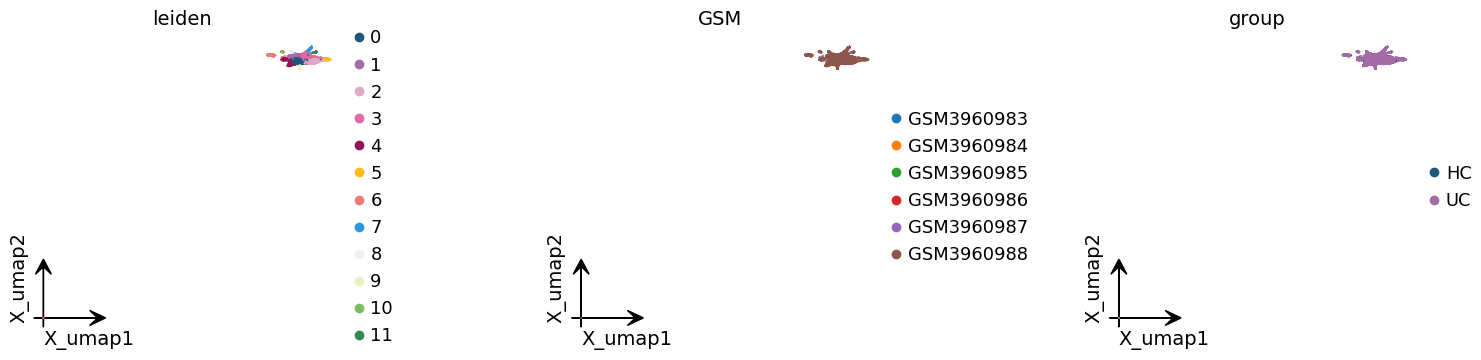

In [22]:
# 可视化查看去除批次效应后聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

## GPT自动注释

In [23]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


{'0': ['S100A10',
  'XCL2',
  'LGALS1',
  'ANXA1',
  'HOPX',
  'CD8B',
  'CAPG',
  'CKLF',
  'ALOX5AP',
  'CCL5'],
 '1': ['GZMH',
  'NKG7',
  'CMC1',
  'CXCR4',
  'GZMK',
  'CST7',
  'TUBA4A',
  'SH2D1A',
  'CD74',
  'ITGB2'],
 '10': ['TRBV7-2', 'TRBV7-4', 'TRBV7-6', 'TRBV7-9', 'TRBV7-7'],
 '11': ['CST3', 'HLA-DRA', 'HLA-DQA1'],
 '2': ['MGAT4A',
  'MAST4',
  'CCR6',
  'SPOCK2',
  'RORA',
  'S100A4',
  'AC092580.4',
  'BATF',
  'KLRB1',
  'CXCR6'],
 '3': ['RP11-290D2.6'],
 '4': ['LAT2',
  'IL2RB',
  'TRDV1',
  'IKZF2',
  'KLRC3',
  'PIK3R1',
  'ID3',
  'LDLRAD4',
  'CD7',
  'KIR2DL4'],
 '5': ['NCR3',
  'NFKBIA',
  'SLC4A10',
  'SPOCK2',
  'IL4I1',
  'LTB',
  'S100A4',
  'KLRB1',
  'TRAV1-2',
  'KLRG1'],
 '6': ['EIF3E',
  'TCF7',
  'CD55',
  'CCR7',
  'EEF1B2',
  'ABLIM1',
  'NOSIP',
  'LDHB',
  'SELL',
  'LEF1'],
 '7': ['NEAT1', 'CTD-3252C9.4', 'EGR1', 'RP11-350N15.5'],
 '8': ['FGFBP2',
  'EMP3',
  'GZMH',
  'NKG7',
  'CTSW',
  'CST7',
  'LITAF',
  'PLEK',
  'ADGRG1',
  'ITGB2'],
 '9': 

In [24]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='T cells',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'Regulatory T cells, Cytotoxic T cells',
 '1': 'Cytotoxic T cells, Natural killer T cells',
 '10': 'T cell receptor gamma delta T cells',
 '11': 'Antigen-presenting cells (non-T cells, likely monocytes or B cells)',
 '2': 'Th17 cells, Regulatory T cells',
 '3': 'Uncertain (low specificity, possibly stromal or non-immune cells)',
 '4': 'Naive T cells, Memory T cells',
 '5': 'Th1 cells, Cytotoxic T cells',
 '6': 'Naive T cells, Central memory T cells',
 '7': 'Activation-induced genes (early activation, multiple T cell types)',
 '8': 'Cytotoxic T cells, Natural killer T cells',
 '9': 'Proliferating cells (cell cycle-active, various T cell subsets)'}

In [25]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

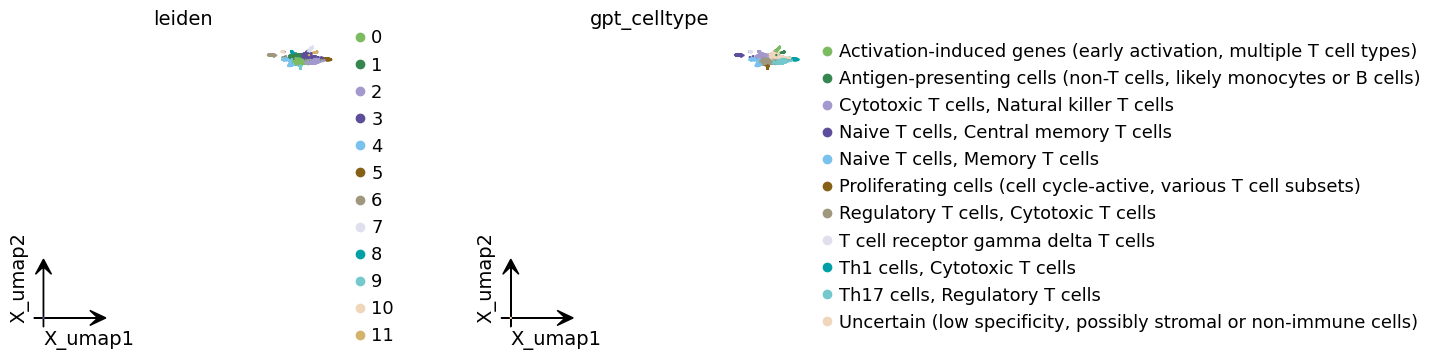

In [26]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [27]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)

gpt_celltype
Regulatory T cells, Cytotoxic T cells                                  28.991433
Cytotoxic T cells, Natural killer T cells                              17.036604
Th17 cells, Regulatory T cells                                         14.145249
Uncertain (low specificity, possibly stromal or non-immune cells)      13.230140
Naive T cells, Memory T cells                                           7.427960
Th1 cells, Cytotoxic T cells                                            6.396028
Naive T cells, Central memory T cells                                   5.305685
Activation-induced genes (early activation, multiple T cell types)      3.679907
Proliferating cells (cell cycle-active, various T cell subsets)         1.547897
T cell receptor gamma delta T cells                                     1.333723
Antigen-presenting cells (non-T cells, likely monocytes or B cells)     0.905374
Name: proportion, dtype: float64
